In [1]:
import sys
sys.path.insert(0, "/home/aronw/Development/Clans-3D")
%load_ext autoreload
%autoreload 2

In [2]:
import Scores_Evaluation.ScoresEvaluator as SE
from InputFileType import InputFileType
print(SE.__file__)

/home/aronw/Development/Clans-3D/Scores_Evaluation/ScoresEvaluator.py


In [3]:
# test-seeds for generated datasets: ["P68871", "Q99895", "P42212", "P00734", "P69905", "P0A6F5"]
PATH_TO_RECOVERED_CLANS = "/home/aronw/Development/clans-recovered" # path to old recovered clans project
CLUSTER_ROUNDS = 100000 # sets the number of rounds for clustering in recovered clans
EXAMPLE_GENERATED_DATA_SETS = {"dataset1": {"size_of_dataset": 30, "number_of_clusters": 1, "seeds": ["P68871"]}}
EXAMPLE_DATASET_FASTA = "/home/aronw/Development/Clans-3D/example_files/datasets_for_evaluation/datasets_fasta"
EXAMPLE_DATASET_TSV = "/home/aronw/Development/Clans-3D/example_files/datasets_for_evaluation/datasets_tsv"

In [4]:
evaluator = SE.ScoresEvaluator(PATH_TO_RECOVERED_CLANS)
structural_vs_sequence_dict = evaluator.initialize_evaluation(
        rounds_to_cluster=CLUSTER_ROUNDS,
        datasets_meta_data=None,
        use_existing_dataset=True,
        path_to_dir_of_existing_datasets=EXAMPLE_DATASET_FASTA,
        datasets_file_type=InputFileType.FASTA
    )

Initializing evaluation...
Failed to download https://alphafold.ebi.ac.uk/files/AF-NOTAVIALABLETEST-F1-model_v6.pdb: 404 Client Error: Not Found for url: https://alphafold.ebi.ac.uk/files/AF-NOTAVIALABLETEST-F1-model_v6.pdb
Downloaded 4 from 5 PDB files successfully.
Computing scores for dataset 5...
Computing structural similarity with foldseek...
Structural similarity computation with foldseek completed.
Generating CLANS file in /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_structsim...
CLANS file generated at /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_structsim/5_cleaned.clans
Running recovered clans.jar on the generated structural clans files...
To honour the JVM settings for this build a single-use Daemon process will be forked. For more on this, please refer to https://docs.gradle.org/8.9/userguide/gradle_daemon.html#sec:disabling_the_daemon in the Gradle documentation.
Daemon will be stopped at the end of the build 
> Task :compileJava UP-TO-



Building a new DB, current time: 11/28/2025 17:52:57
New DB name:   /home/aronw/Development/Clans-3D/Scores_Evaluation/blast_files/temp_blast_db
New DB title:  /home/aronw/Development/Clans-3D/Scores_Evaluation/datasets/5_cleaned.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 4 sequences in 0.00299406 seconds.


Generating CLANS file in /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_seqsim...
CLANS file generated at /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_seqsim/5_cleaned.clans
To honour the JVM settings for this build a single-use Daemon process will be forked. For more on this, please refer to https://docs.gradle.org/8.9/userguide/gradle_daemon.html#sec:disabling_the_daemon in the Gradle documentation.
Daemon will be stopped at the end of the build 
> Task :compileJava UP-TO-DATE
> Task :processResources NO-SOURCE
> Task :classes UP-TO-DATE

> Task :run
new CLANS
------------------S

Evaluating structural clans file /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_structsim/5_cleaned_out.clans with sequence clans file /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_seqsim/5_cleaned_out.clans...
Parsing CLANS file /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_structsim/5_cleaned_out.clans...
Parsing CLANS file /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_seqsim/5_cleaned_out.clans...
   PDBchain1  PDBchain2  score_struct      score_seq  score_struct_log10  \
0          0          1  1.179000e-30   0.000000e+00           29.928486   
1          0          2  1.521000e-29   0.000000e+00           28.817871   
2          0          3  2.112000e-18  5.110000e-130           17.675306   
3          1          2  1.531000e-42   0.000000e+00           41.815025   
4          1          3  1.061000e-27  6.070000e-128           26.974285   
5          2          3  2.973000e-28  2.330000e-128           27.526805 

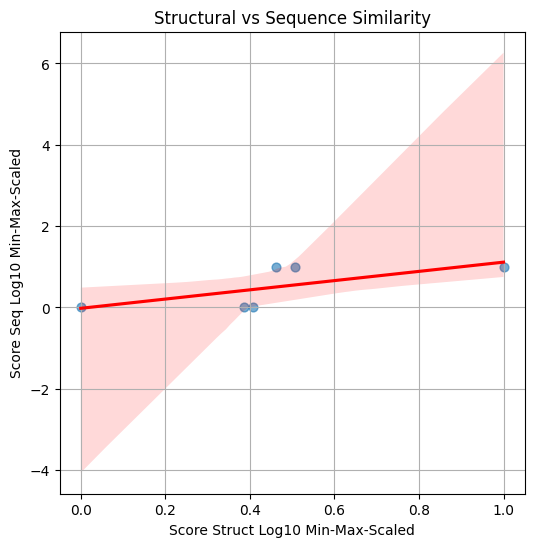

In [5]:
evaluation_results_df = evaluator.evaluate(structural_vs_sequence_dict)